In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import copy

from torchvision.models import resnet18
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2
from torchvision import models

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import label_binarize


(1, 150, 150)


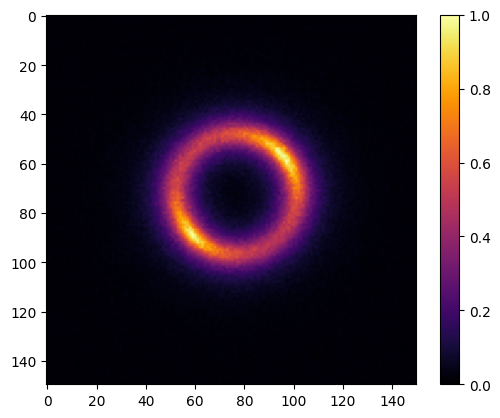

In [2]:
sample_path = '/Users/ishaan/Documents/DeepLense/dataset/train/no'

file = os.listdir(sample_path)[0]

image = np.load(os.path.join(sample_path, file))

print(image.shape)

plt.imshow(image.squeeze(0), cmap='inferno')
plt.colorbar()
plt.show()

In [3]:
class_map = {
    'no': 0,
    'sphere': 1,
    'vort': 2
}

In [4]:
class AddGaussianNoise(torch.nn.Module):
    def __init__(self, mean=0., std=0.05):
        super().__init__()
        self.mean = mean
        self.std = std

    def forward(self, tensor):
        noise = torch.randn_like(tensor) * self.std + self.mean
        return tensor + noise

In [5]:
class LensDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.samples = []
        self.labels = []
        self.transform = transform

        for cls in class_map.keys():
            folder = os.path.join(root_dir, cls)
            if not os.path.exists(folder):
                continue

            for file in os.listdir(folder):
                if file.endswith('.npy'):
                    path = os.path.join(folder, file)
                    self.samples.append(path)
                    self.labels.append(class_map[cls])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        image = np.load(self.samples[idx])
        image_tensor = torch.tensor(image, dtype=torch.float32)

        if image_tensor.dim() > 2:
            image_tensor = image_tensor.squeeze()

        image_tensor = image_tensor.unsqueeze(0)

        if self.transform:
            image_tensor = self.transform(image_tensor)

        image_tensor = torch.log1p(image_tensor - image_tensor.min())
        mean = image_tensor.mean()
        std = image_tensor.std()
        image_tensor = (image_tensor - mean) / (std + 1e-8)

        label = self.labels[idx]
        return image_tensor, label


class BaselineLensDataset(LensDataset):

    def __init__(self, root_dir, transform=None):
        super().__init__(root_dir, transform=transform)
        self.sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        self.sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)

    def __getitem__(self, idx):
        image_tensor, label = super().__getitem__(idx)
        img_for_conv = image_tensor.unsqueeze(0)
        grad_x = F.conv2d(img_for_conv, self.sobel_x, padding=1).squeeze(0)
        grad_y = F.conv2d(img_for_conv, self.sobel_y, padding=1).squeeze(0)
        combined_tensor = torch.cat((image_tensor, grad_x, grad_y), dim=0)
        return combined_tensor, label

In [6]:
train_transforms = v2.Compose([
    v2.RandomAffine(
        degrees=(0, 360),
        translate=(0.1, 0.1),
        fill=0
    ),
    AddGaussianNoise(mean=0., std=0.05)
])

val_transforms = None

train_dataset = LensDataset('/Users/ishaan/Documents/DeepLense/dataset/train', transform=train_transforms)
val_dataset = LensDataset('/Users/ishaan/Documents/DeepLense/dataset/val', transform=val_transforms)

baseline_train_dataset = BaselineLensDataset('/Users/ishaan/Documents/DeepLense/dataset/train', transform=train_transforms)
baseline_val_dataset = BaselineLensDataset('/Users/ishaan/Documents/DeepLense/dataset/val', transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

baseline_train_loader = DataLoader(baseline_train_dataset, batch_size=32, shuffle=True)
baseline_val_loader = DataLoader(baseline_val_dataset, batch_size=32)

In [7]:
def get_resnet_model(num_classes=3):

    try:
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        print('Loaded pretrained ResNet18 weights')
    except Exception:
        model = models.resnet18(weights=None)
        print('Could not load pretrained weights, using randomly initialized ResNet18')

    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model


device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Training on: {device}')

Training on: mps


In [8]:
def total_variation_loss(k_map):
    diff_h = torch.abs(k_map[:, :, 1:, :] - k_map[:, :, :-1, :]).mean()
    diff_w = torch.abs(k_map[:, :, :, 1:] - k_map[:, :, :, :-1]).mean()
    return diff_h + diff_w


def evaluate_model(model, data_loader, physics_model=False):

    model.eval()

    all_labels = []
    all_probs = []

    with torch.no_grad():

        for images, labels in data_loader:
            images = images.to(device)

            if physics_model:
                outputs, _, _, _ = model(images)
            else:
                outputs = model(images)

            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu())
            all_labels.append(labels)

    all_probs = torch.cat(all_probs)
    all_labels = torch.cat(all_labels)

    y_true = all_labels.numpy()
    y_score = all_probs.numpy()
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

    auc = roc_auc_score(y_true_bin, y_score, multi_class='ovr')

    return auc, y_true, y_score, y_true_bin


def plot_roc_curves(y_true_bin, y_score, title):
    classes = ['No Substructure', 'Sphere', 'Vortex']
    colors = ['blue', 'red', 'green']

    plt.figure(figsize=(8, 6))

    for i in range(3):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        class_auc = roc_auc_score(y_true_bin[:, i], y_score[:, i])
        plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{classes[i]} (AUC = {class_auc:.4f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()


def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    classes = ['No Substructure', 'Sphere', 'Vortex']

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, cmap='Blues')
    plt.title(title)
    plt.colorbar()
    plt.xticks(range(3), classes, rotation=20)
    plt.yticks(range(3), classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center', color='black')

    plt.tight_layout()
    plt.show()

In [9]:
baseline_model = get_resnet_model().to(device)

criterion = nn.CrossEntropyLoss()
baseline_optimizer = optim.AdamW(baseline_model.parameters(), lr=1e-4, weight_decay=1e-4)
baseline_scheduler = optim.lr_scheduler.CosineAnnealingLR(baseline_optimizer, T_max=12)

baseline_epochs = 10
best_baseline_auc = 0.0
best_baseline_weights = copy.deepcopy(baseline_model.state_dict())

for epoch in range(baseline_epochs):

    baseline_model.train()
    total_loss = 0.0

    for images, labels in baseline_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        baseline_optimizer.zero_grad()

        outputs = baseline_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        baseline_optimizer.step()

        total_loss += loss.item()

    baseline_scheduler.step()

    val_auc, _, _, _ = evaluate_model(baseline_model, baseline_val_loader, physics_model=False)

    if val_auc > best_baseline_auc:
        best_baseline_auc = val_auc
        best_baseline_weights = copy.deepcopy(baseline_model.state_dict())

    print(f'Epoch {epoch + 1}/{baseline_epochs} - Loss: {total_loss / len(baseline_train_loader):.4f} - Val AUC: {val_auc:.4f}')

baseline_model.load_state_dict(best_baseline_weights)
print(f'Best Baseline AUC: {best_baseline_auc:.4f}')

Loaded pretrained ResNet18 weights
Epoch 1/10 - Loss: 1.1154 - Val AUC: 0.5857
Epoch 2/10 - Loss: 1.0672 - Val AUC: 0.6916
Epoch 3/10 - Loss: 0.9980 - Val AUC: 0.7514
Epoch 4/10 - Loss: 0.9304 - Val AUC: 0.7811
Epoch 5/10 - Loss: 0.8697 - Val AUC: 0.8069
Epoch 6/10 - Loss: 0.8338 - Val AUC: 0.8042
Epoch 7/10 - Loss: 0.7975 - Val AUC: 0.8159
Epoch 8/10 - Loss: 0.7695 - Val AUC: 0.8439
Epoch 9/10 - Loss: 0.7422 - Val AUC: 0.8274
Epoch 10/10 - Loss: 0.7308 - Val AUC: 0.8255
Best Baseline AUC: 0.8439


Baseline AUC Score: 0.8438652400000001


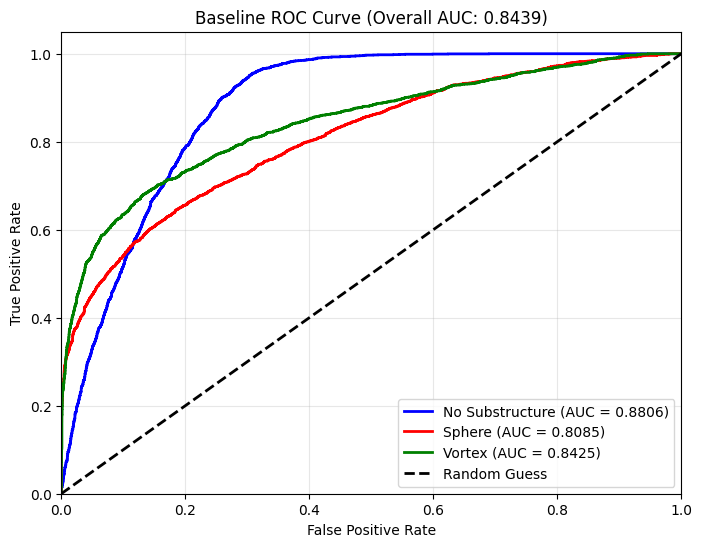

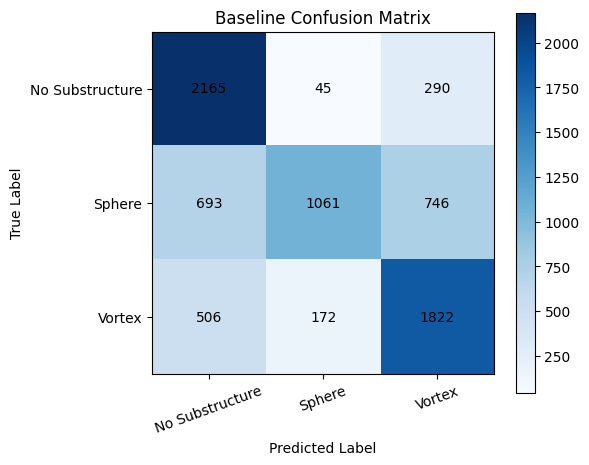

In [10]:
baseline_auc, baseline_y_true, baseline_y_score, baseline_y_true_bin = evaluate_model(
    baseline_model,
    baseline_val_loader,
    physics_model=False
)

print('Baseline AUC Score:', baseline_auc)

plot_roc_curves(
    baseline_y_true_bin,
    baseline_y_score,
    f'Baseline ROC Curve (Overall AUC: {baseline_auc:.4f})'
)

baseline_preds = baseline_y_score.argmax(axis=1)
plot_confusion(baseline_y_true, baseline_preds, 'Baseline Confusion Matrix')


In [11]:
class PhysicsLayer(nn.Module):
    def __init__(self, image_size=150):
        super().__init__()
        self.image_size = image_size

        self.k_predictor = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, kernel_size=3, padding=1)
        )

        self.theta_E = nn.Parameter(torch.tensor(0.5))

        y_grid, x_grid = torch.meshgrid(
            torch.linspace(-1, 1, image_size),
            torch.linspace(-1, 1, image_size),
            indexing='ij'
        )

        base_grid = torch.stack([x_grid, y_grid], dim=-1).unsqueeze(0)
        radius = torch.sqrt(x_grid ** 2 + y_grid ** 2 + 1e-6).unsqueeze(0).unsqueeze(0)

        sobel_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]], dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]], dtype=torch.float32).view(1, 1, 3, 3)

        self.register_buffer('base_grid', base_grid.float())
        self.register_buffer('radius', radius.float())
        self.register_buffer('sobel_x', sobel_x)
        self.register_buffer('sobel_y', sobel_y)

    def bilinear_sample(self, x, source_grid):
        batch_size, channels, height, width = x.shape

        x_coords = ((source_grid[..., 0] + 1) * 0.5) * (width - 1)
        y_coords = ((source_grid[..., 1] + 1) * 0.5) * (height - 1)

        x_coords = x_coords.clamp(0, width - 1 - 1e-6)
        y_coords = y_coords.clamp(0, height - 1 - 1e-6)

        x0 = torch.floor(x_coords).long()
        y0 = torch.floor(y_coords).long()
        x1 = (x0 + 1).clamp(max=width - 1)
        y1 = (y0 + 1).clamp(max=height - 1)

        flat = x.reshape(batch_size, channels, height * width)

        def gather_pixels(x_idx, y_idx):
            index = (y_idx * width + x_idx).reshape(batch_size, 1, -1).expand(-1, channels, -1)
            values = flat.gather(2, index)
            return values.reshape(batch_size, channels, height, width)

        top_left = gather_pixels(x0, y0)
        bottom_left = gather_pixels(x0, y1)
        top_right = gather_pixels(x1, y0)
        bottom_right = gather_pixels(x1, y1)

        x0 = x0.float()
        x1 = x1.float()
        y0 = y0.float()
        y1 = y1.float()

        wa = ((x1 - x_coords) * (y1 - y_coords)).unsqueeze(1)
        wb = ((x1 - x_coords) * (y_coords - y0)).unsqueeze(1)
        wc = ((x_coords - x0) * (y1 - y_coords)).unsqueeze(1)
        wd = ((x_coords - x0) * (y_coords - y0)).unsqueeze(1)

        sampled = top_left * wa + bottom_left * wb + top_right * wc + bottom_right * wd
        return sampled

    def forward(self, x):
        delta_k = self.k_predictor(x)
        theta_E = torch.abs(self.theta_E) + 1e-6
        k_map = theta_E * (1 + 0.2 * torch.tanh(delta_k))

        psi = k_map * self.radius

        grad_x = F.conv2d(psi, self.sobel_x, padding=1) / 8.0
        grad_y = F.conv2d(psi, self.sobel_y, padding=1) / 8.0

        batch_size = x.size(0)
        image_grid = self.base_grid.expand(batch_size, -1, -1, -1)

        source_grid_x = image_grid[..., 0] - grad_x.squeeze(1)
        source_grid_y = image_grid[..., 1] - grad_y.squeeze(1)
        source_grid = torch.stack([source_grid_x, source_grid_y], dim=-1)
        source_grid = source_grid.clamp(-1, 1)

        de_lensed = self.bilinear_sample(x, source_grid)
        residual = x - de_lensed

        return de_lensed, residual, k_map


class PhysicsGuidedResNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.physics_layer = PhysicsLayer(image_size=150)
        self.backbone = get_resnet_model(num_classes=num_classes)

    def forward(self, x):
        de_lensed, residual, k_map = self.physics_layer(x)
        combined = torch.cat([x, de_lensed, residual], dim=1)
        combined = F.interpolate(combined, size=(224, 224), mode='bilinear', align_corners=False)
        logits = self.backbone(combined)
        return logits, k_map, de_lensed, residual

In [12]:
model = PhysicsGuidedResNet(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=18)

print(f'Initial theta_E: {(torch.abs(model.physics_layer.theta_E) + 1e-6).item():.4f}')

Loaded pretrained ResNet18 weights
Initial theta_E: 0.5000


In [13]:
epochs = 20
best_auc = 0.0
best_weights = copy.deepcopy(model.state_dict())

for epoch in range(epochs):

    model.train()
    total_loss = 0.0
    total_ce = 0.0
    total_tv = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs, k_map, _, _ = model(images)
        ce_loss = criterion(outputs, labels)
        smooth_loss = total_variation_loss(k_map)
        loss = ce_loss + 1e-4 * smooth_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_ce += ce_loss.item()
        total_tv += smooth_loss.item()

    scheduler.step()

    val_auc, _, _, _ = evaluate_model(model, val_loader, physics_model=True)

    if val_auc > best_auc:
        best_auc = val_auc
        best_weights = copy.deepcopy(model.state_dict())

    current_theta = (torch.abs(model.physics_layer.theta_E) + 1e-6).item()

    print(
        f'Epoch {epoch + 1}/{epochs} - Loss: {total_loss / len(train_loader):.4f} ' 
        f'- CE: {total_ce / len(train_loader):.4f} ' 
        f'- TV: {total_tv / len(train_loader):.4f} ' 
        f'- Val AUC: {val_auc:.4f} ' 
        f'- theta_E: {current_theta:.4f}'
    )

model.load_state_dict(best_weights)
print(f'Best Physics-Guided AUC: {best_auc:.4f}')

Epoch 1/20 - Loss: 1.1083 - CE: 1.1083 - TV: 0.0093 - Val AUC: 0.5976 - theta_E: 0.5000
Epoch 2/20 - Loss: 1.0333 - CE: 1.0333 - TV: 0.0088 - Val AUC: 0.7282 - theta_E: 0.4951
Epoch 3/20 - Loss: 0.9162 - CE: 0.9162 - TV: 0.0084 - Val AUC: 0.8037 - theta_E: 0.4911
Epoch 4/20 - Loss: 0.8386 - CE: 0.8386 - TV: 0.0089 - Val AUC: 0.8468 - theta_E: 0.4934
Epoch 5/20 - Loss: 0.7841 - CE: 0.7841 - TV: 0.0090 - Val AUC: 0.8664 - theta_E: 0.4901
Epoch 6/20 - Loss: 0.7493 - CE: 0.7493 - TV: 0.0100 - Val AUC: 0.8470 - theta_E: 0.4891
Epoch 7/20 - Loss: 0.7197 - CE: 0.7197 - TV: 0.0114 - Val AUC: 0.8405 - theta_E: 0.4893
Epoch 8/20 - Loss: 0.6963 - CE: 0.6963 - TV: 0.0121 - Val AUC: 0.8072 - theta_E: 0.4902
Epoch 9/20 - Loss: 0.6790 - CE: 0.6790 - TV: 0.0123 - Val AUC: 0.8535 - theta_E: 0.4904
Epoch 10/20 - Loss: 0.6545 - CE: 0.6545 - TV: 0.0124 - Val AUC: 0.8471 - theta_E: 0.4909
Epoch 11/20 - Loss: 0.6370 - CE: 0.6370 - TV: 0.0128 - Val AUC: 0.8773 - theta_E: 0.4905
Epoch 12/20 - Loss: 0.6256 - C

Physics Guided AUC Score: 0.8772719466666667


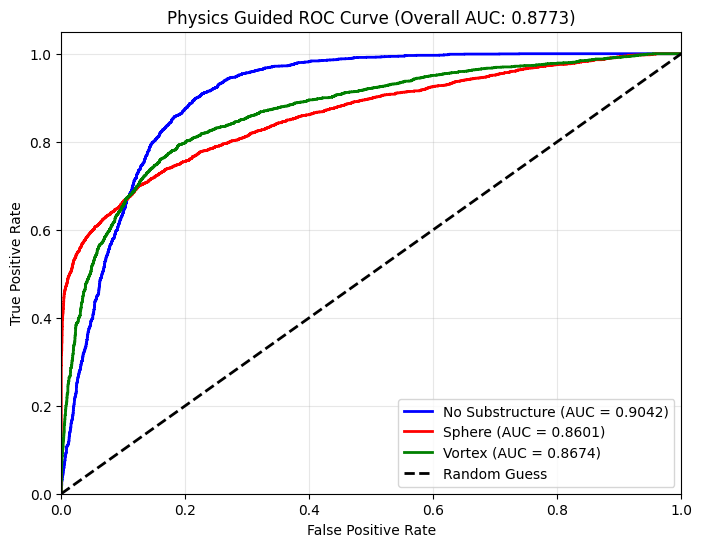

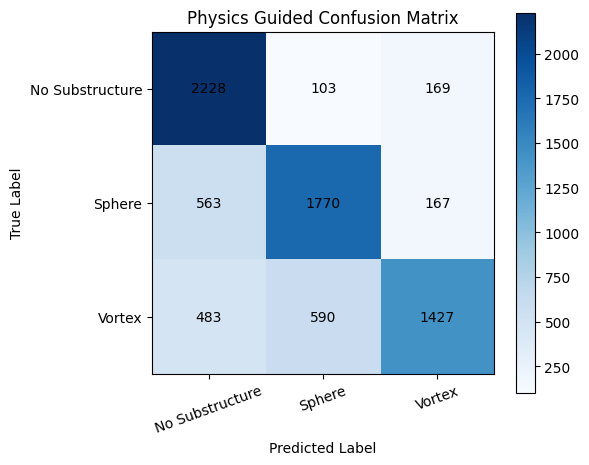

Learned theta_E: 0.4905


In [14]:
auc, y_true, y_score, y_true_bin = evaluate_model(model, val_loader, physics_model=True)

print('Physics Guided AUC Score:', auc)

plot_roc_curves(
    y_true_bin,
    y_score,
    f'Physics Guided ROC Curve (Overall AUC: {auc:.4f})'
)

preds = y_score.argmax(axis=1)
plot_confusion(y_true, preds, 'Physics Guided Confusion Matrix')

print(f'Learned theta_E: {(torch.abs(model.physics_layer.theta_E) + 1e-6).item():.4f}')


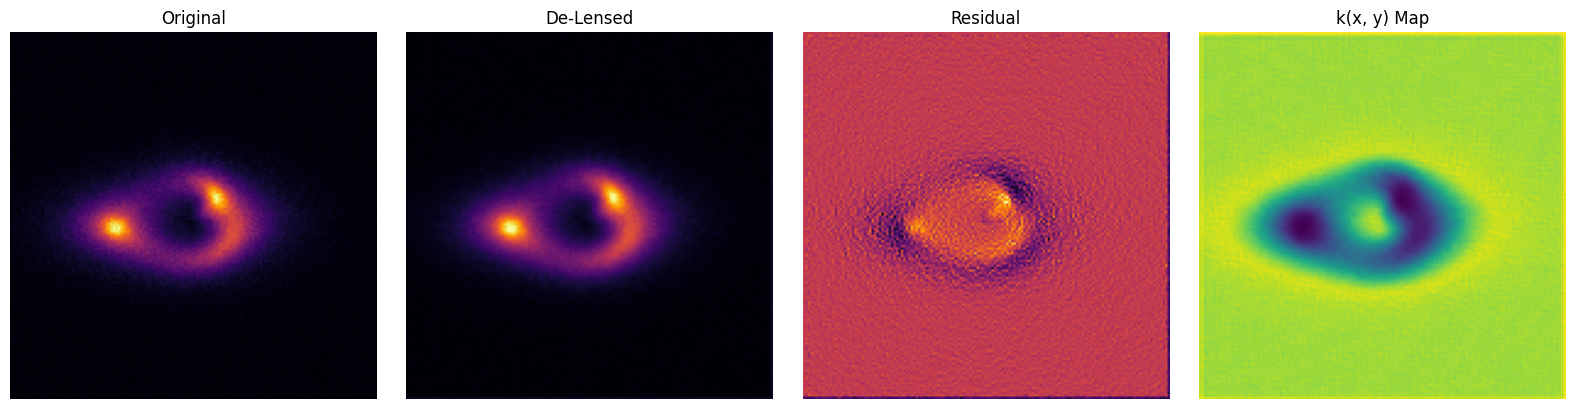

In [15]:
model.eval()

images, labels = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    outputs, k_map, de_lensed, residual = model(images)

idx = 0

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(images[idx].cpu().squeeze(0), cmap='inferno')
axes[0].set_title('Original')
axes[1].imshow(de_lensed[idx].cpu().squeeze(0), cmap='inferno')
axes[1].set_title('De-Lensed')
axes[2].imshow(residual[idx].cpu().squeeze(0), cmap='inferno')
axes[2].set_title('Residual')
axes[3].imshow(k_map[idx].cpu().squeeze(0), cmap='viridis')
axes[3].set_title('k(x, y) Map')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [18]:
print(f'Baseline AUC: {baseline_auc:.4f}')
print(f'Physics Guided AUC: {auc:.4f}')
if auc > baseline_auc:
    print('Physics guided model improved over the baseline.')

Baseline AUC: 0.8439
Physics Guided AUC: 0.8773
Physics guided model improved over the baseline.
